#### 33kV Incoming Feeder Daily Data: Wide to Long

This notebook starts by reshaping the raw wide-format feeder workbook into a long table where each day becomes its own row.

Source file:

- `raw_data/20260407_33kVIncomingFeederDailyDataWide.xlsx`

Guardrails for this step:

- keep path handling aligned with the shared project helpers
- do not silently drop missing values during the reshape
- keep the long output in `data/processed/` as Parquet for later reuse
- leave room for future combined analysis without forcing any unsupported joins

In [1]:
from __future__ import annotations

from datetime import date, datetime
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    """Walk upward until the repository root is found."""

    start_path = (start or Path.cwd()).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src").exists() and (candidate / "config").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing src/ and config/.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: F:\Secure\CashFlowMgmt


In [2]:
from src.path_utils import build_project_paths, load_app_config


APP_CONFIG = load_app_config(PROJECT_ROOT / "config" / "app_config.yaml")
PROJECT_PATHS = build_project_paths(
    base_dir=PROJECT_ROOT,
    base_dir_source="notebook",
    app_config=APP_CONFIG,
)

SOURCE_FILENAME = "20260407_33kVIncomingFeederDailyDataWide.xlsx"
RECHARGE_SOURCE_FILENAME = "20260407_RechargeToDate.csv"
OUTPUT_FILENAME = "33kv_incoming_feeder_daily_long.parquet"
VEND_DAILY_OUTPUT_FILENAME = "vend_amounts_daily.parquet"
SUMMARY_XLSX_FILENAME = "33kv_incoming_feeder_daily_summary.xlsx"
SUMMARY_PNG_FILENAME = "33kv_incoming_feeder_daily_summary.png"
WEEKDAY_SUMMARY_XLSX_FILENAME = "33kv_incoming_feeder_weekday_summary.xlsx"
SPECIAL_DAY_SUMMARY_XLSX_FILENAME = "33kv_incoming_feeder_special_day_summary.xlsx"
TREND_PNG_FILENAME = "33kv_incoming_feeder_kwh_vend_trend.png"
WEEKDAY_PROFILE_PNG_FILENAME = "33kv_incoming_feeder_weekday_profile.png"
WEEKDAY_CV_PNG_FILENAME = "33kv_incoming_feeder_weekday_cv_comparison.png"
WEEKDAY_BOXPLOT_PNG_FILENAME = "33kv_incoming_feeder_weekday_boxplots.png"
SPECIAL_GROUP_BOXPLOT_PNG_FILENAME = "33kv_incoming_feeder_special_day_boxplots.png"
SPECIAL_DAY_CV_PNG_FILENAME = "33kv_incoming_feeder_special_day_cv_comparison.png"
SCATTER_PNG_FILENAME = "33kv_incoming_feeder_kwh_vs_vend_scatter.png"
MONTHLY_PROFILE_PNG_FILENAME = "33kv_incoming_feeder_monthly_profile.png"
INDEXED_TREND_PNG_FILENAME = "33kv_incoming_feeder_indexed_trend.png"
HEATMAP_PNG_FILENAME = "33kv_incoming_feeder_weekday_month_heatmap.png"
SHEET_NAME = "Day wise summary"

source_path = PROJECT_PATHS.raw_data_dir / SOURCE_FILENAME
recharge_source_path = PROJECT_PATHS.raw_data_dir / RECHARGE_SOURCE_FILENAME
output_path = PROJECT_PATHS.processed_data_dir / OUTPUT_FILENAME
vend_daily_output_path = PROJECT_PATHS.processed_data_dir / VEND_DAILY_OUTPUT_FILENAME
data_dir = PROJECT_ROOT / "data"
summary_xlsx_path = data_dir / SUMMARY_XLSX_FILENAME
summary_png_path = data_dir / SUMMARY_PNG_FILENAME
weekday_summary_xlsx_path = data_dir / WEEKDAY_SUMMARY_XLSX_FILENAME
special_day_summary_xlsx_path = data_dir / SPECIAL_DAY_SUMMARY_XLSX_FILENAME
trend_png_path = data_dir / TREND_PNG_FILENAME
weekday_profile_png_path = data_dir / WEEKDAY_PROFILE_PNG_FILENAME
weekday_cv_png_path = data_dir / WEEKDAY_CV_PNG_FILENAME
weekday_boxplot_png_path = data_dir / WEEKDAY_BOXPLOT_PNG_FILENAME
special_group_boxplot_png_path = data_dir / SPECIAL_GROUP_BOXPLOT_PNG_FILENAME
special_day_cv_png_path = data_dir / SPECIAL_DAY_CV_PNG_FILENAME
scatter_png_path = data_dir / SCATTER_PNG_FILENAME
monthly_profile_png_path = data_dir / MONTHLY_PROFILE_PNG_FILENAME
indexed_trend_png_path = data_dir / INDEXED_TREND_PNG_FILENAME
heatmap_png_path = data_dir / HEATMAP_PNG_FILENAME

print(f"Source workbook: {source_path}")
print(f"Recharge source CSV: {recharge_source_path}")
print(f"Output Parquet: {output_path}")
print(f"Vend daily Parquet: {vend_daily_output_path}")
print(f"Summary workbook: {summary_xlsx_path}")
print(f"Summary chart: {summary_png_path}")
print(f"Weekday summary workbook: {weekday_summary_xlsx_path}")
print(f"Special day summary workbook: {special_day_summary_xlsx_path}")
print(f"Trend chart: {trend_png_path}")
print(f"Weekday profile chart: {weekday_profile_png_path}")
print(f"Weekday CV chart: {weekday_cv_png_path}")
print(f"Weekday boxplot chart: {weekday_boxplot_png_path}")
print(f"Special day boxplot chart: {special_group_boxplot_png_path}")
print(f"Special day CV chart: {special_day_cv_png_path}")
print(f"Scatter chart: {scatter_png_path}")
print(f"Monthly profile chart: {monthly_profile_png_path}")
print(f"Indexed trend chart: {indexed_trend_png_path}")
print(f"Heatmap chart: {heatmap_png_path}")

Source workbook: F:\Secure\CashFlowMgmt\raw_data\20260407_33kVIncomingFeederDailyDataWide.xlsx
Recharge source CSV: F:\Secure\CashFlowMgmt\raw_data\20260407_RechargeToDate.csv
Output Parquet: F:\Secure\CashFlowMgmt\data\processed\33kv_incoming_feeder_daily_long.parquet
Vend daily Parquet: F:\Secure\CashFlowMgmt\data\processed\vend_amounts_daily.parquet
Summary workbook: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_daily_summary.xlsx
Summary chart: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_daily_summary.png
Weekday summary workbook: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_weekday_summary.xlsx
Special day summary workbook: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_special_day_summary.xlsx
Trend chart: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_kwh_vend_trend.png
Weekday profile chart: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_weekday_profile.png
Weekday CV chart: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_weekday_cv_comparison.png
Weekday box

In [3]:
EXPECTED_ID_COLUMNS = [
    "Zone",
    "Circle",
    "division",
    "subdivision",
    "section",
    "Substation",
    "Feeder",
    "Attribute",
    "Supply voltage",
    "Meter no",
    "MF",
    "Meter id",
]

PARQUET_SAFE_TEXT_COLUMNS = [
    "Zone",
    "Circle",
    "division",
    "subdivision",
    "section",
    "Substation",
    "Feeder",
    "Attribute",
    "Supply voltage",
    "Meter no",
    "Meter id",
]


def coerce_header_to_date(value: object) -> pd.Timestamp | None:
    """Return a normalized timestamp when a column header represents a date."""

    if isinstance(value, pd.Timestamp):
        return value.normalize()
    if isinstance(value, datetime):
        return pd.Timestamp(value).normalize()
    if isinstance(value, date):
        return pd.Timestamp(value)

    if isinstance(value, (int, float)) and 20000 <= float(value) <= 60000:
        # Excel serial dates in headers should convert to calendar dates explicitly.
        return pd.Timestamp("1899-12-30") + pd.to_timedelta(int(value), unit="D")

    if isinstance(value, str):
        cleaned = value.strip()
        if not cleaned:
            return None
        parsed = pd.to_datetime(cleaned, errors="coerce")
        if pd.notna(parsed):
            return parsed.normalize()

    return None


def standardize_wide_columns(columns: pd.Index) -> list[str]:
    """Convert date-like headers to ISO dates while preserving identifier columns."""

    standardized: list[str] = []
    for column in columns:
        parsed_date = coerce_header_to_date(column)
        if parsed_date is not None:
            standardized.append(parsed_date.strftime("%Y-%m-%d"))
        else:
            standardized.append(str(column).strip())
    return standardized


def split_id_and_date_columns(columns: list[str]) -> tuple[list[str], list[str]]:
    """Separate the feeder descriptor columns from the daily date columns."""

    id_columns: list[str] = []
    date_columns: list[str] = []
    for column in columns:
        if pd.notna(pd.to_datetime(column, errors="coerce")):
            date_columns.append(column)
        else:
            id_columns.append(column)
    return id_columns, date_columns


def normalize_text_identifier_columns(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Cast identifier-like text columns to pandas string dtype for Parquet safety."""

    normalized = frame.copy()
    for column in columns:
        if column not in normalized.columns:
            continue

        normalized[column] = normalized[column].astype("string").str.strip()
        normalized.loc[normalized[column].isin(["", "nan", "None", "<NA>"]), column] = pd.NA

    return normalized


def summarize_reshape(wide_df: pd.DataFrame, long_df: pd.DataFrame, id_columns: list[str], date_columns: list[str]) -> pd.DataFrame:
    """Build a compact diagnostic summary for the reshape step."""

    date_index = pd.to_datetime(date_columns)
    return pd.DataFrame([
        {
            "wide_rows": len(wide_df),
            "wide_columns": len(wide_df.columns),
            "id_column_count": len(id_columns),
            "date_column_count": len(date_columns),
            "date_min": date_index.min(),
            "date_max": date_index.max(),
            "long_rows": len(long_df),
            "null_kwh_rows": int(long_df["kWh"].isna().sum()),
            "duplicate_id_date_rows": int(long_df.duplicated(subset=id_columns + ["reading_date"]).sum()),
        }
    ])

In [4]:
wide_df = pd.read_excel(source_path, sheet_name=SHEET_NAME)
wide_df.columns = standardize_wide_columns(wide_df.columns)

id_columns, date_columns = split_id_and_date_columns(wide_df.columns.tolist())
missing_expected_id_columns = [column for column in EXPECTED_ID_COLUMNS if column not in id_columns]
unexpected_id_columns = [column for column in id_columns if column not in EXPECTED_ID_COLUMNS]

print(f"Wide shape: {wide_df.shape}")
print(f"Identifier columns: {len(id_columns)}")
print(f"Date columns: {len(date_columns)}")

if missing_expected_id_columns:
    print("Missing expected identifier columns:", missing_expected_id_columns)
if unexpected_id_columns:
    print("Unexpected non-date columns kept as identifiers:", unexpected_id_columns)

display(pd.DataFrame({
    "id_columns": pd.Series(id_columns),
    "date_columns_preview": pd.Series(date_columns[: len(id_columns)]),
}).fillna(""))

display(wide_df.head())

Wide shape: (174, 377)
Identifier columns: 12
Date columns: 365


,id_columns,date_columns_preview
0,Zone,2025-04-01
1,Circle,2025-04-02
2,division,2025-04-03
3,subdivision,2025-04-04
4,section,2025-04-05
5,Substation,2025-04-06
6,Feeder,2025-04-07
7,Attribute,2025-04-08
8,Supply voltage,2025-04-09
9,Meter no,2025-04-10


,Zone,Circle,division,subdivision,section,Substation,Feeder,Attribute,Supply voltage,Meter no,...,2026-03-22,2026-03-23,2026-03-24,2026-03-25,2026-03-26,2026-03-27,2026-03-28,2026-03-29,2026-03-30,2026-03-31
0,NBPDCL,MOTIHARI,CHAKIA,MADHUBAN_CHAKIA,TETARIA_NEW,Tataria,33 KV IC TETARIYA GSS,Incomer,33kV,BEB54067,...,400,0,400,200,400,0,200,0,200,1200
1,NBPDCL,MOTIHARI,RAXAUL,GHORASAHAN,BANKATWA,33 KV Bankatwa Kodarcut,33 KV IC BANKATWA GSS,Incomer,33kV,BEB54076,...,0,0,0,0,0,0,0,0,0,0
2,NBPDCL,MUZAFFARPUR,MUZAFFARPUR(E),MUJJAFARPUR(E),MINAPUR,Banghara,33KV INCOMING BANGHARA_FD526,Incomer,33kV,MS600025,...,98104.0,115672.0,121192.0,128224.0,115736.0,131000,110432.0,134200,142184.0,150424.0
3,NBPDCL,MOTIHARI,CHAKIA,KESHARIA,KALYANPUR_NEW,Kalyanpur,33 KV I/C KALYANPUR._FD678,Incomer,33kV,NBPD9745,...,86200,97000,102200,101000,107000,107800,106700,115500,117800,124800
4,NBPDCL,MOTIHARI,CHAKIA,ARERAJ_NEW,HARSIDHI_NEW,33/11 KV Harsidhi,33KV I/C MOTIHARI_FD711,Incomer,33kV,NBPD9747,...,81400,95600,102900,110600,116500,117500,114400,123800,126700,124800


In [5]:
long_df = (
    wide_df.melt(
        id_vars=id_columns,
        value_vars=date_columns,
        var_name="reading_date",
        value_name="kWh",
    )
    .assign(
        reading_date=lambda frame: pd.to_datetime(frame["reading_date"], errors="coerce"),
        kWh=lambda frame: pd.to_numeric(frame["kWh"], errors="coerce"),
    )
    .sort_values(["Meter id", "reading_date"])
    .reset_index(drop=True)
)

# Keep identifier-like fields as text so mixed values such as alphanumeric meter numbers
# do not fail Parquet conversion when Arrow tries to infer a numeric type.
long_df = normalize_text_identifier_columns(long_df, PARQUET_SAFE_TEXT_COLUMNS)

display(long_df.head())
display(long_df.tail())
display(long_df[PARQUET_SAFE_TEXT_COLUMNS].dtypes.rename("dtype"))

,Zone,Circle,division,subdivision,section,Substation,Feeder,Attribute,Supply voltage,Meter no,MF,Meter id,reading_date,kWh
0,NBPDCL,MOTIHARI,MOTIHARI,MOTIHARI,MOTIHARI(R),Dhurv Lakhaura,33 KV JAMLA PSS,Incomer,33kV,17131000,4.0,71,2025-04-01,NaN
1,NBPDCL,MOTIHARI,MOTIHARI,MOTIHARI,MOTIHARI(R),Dhurv Lakhaura,33 KV JAMLA PSS,Incomer,33kV,17131000,4.0,71,2025-04-02,NaN
2,NBPDCL,MOTIHARI,MOTIHARI,MOTIHARI,MOTIHARI(R),Dhurv Lakhaura,33 KV JAMLA PSS,Incomer,33kV,17131000,4.0,71,2025-04-03,NaN
3,NBPDCL,MOTIHARI,MOTIHARI,MOTIHARI,MOTIHARI(R),Dhurv Lakhaura,33 KV JAMLA PSS,Incomer,33kV,17131000,4.0,71,2025-04-04,NaN
4,NBPDCL,MOTIHARI,MOTIHARI,MOTIHARI,MOTIHARI(R),Dhurv Lakhaura,33 KV JAMLA PSS,Incomer,33kV,17131000,4.0,71,2025-04-05,NaN


,Zone,Circle,division,subdivision,section,Substation,Feeder,Attribute,Supply voltage,Meter no,MF,Meter id,reading_date,kWh
63505,NBPDCL,MOTIHARI,BAGHA,BAGHA_NEW,KUMHIA,33/11 KV Kumbhiya Bishunpurwa,33 kV IC KUMIYA BISHANPURA,Incomer,33kV,NB50019667,600.0,4524651,2026-03-27,NaN
63506,NBPDCL,MOTIHARI,BAGHA,BAGHA_NEW,KUMHIA,33/11 KV Kumbhiya Bishunpurwa,33 kV IC KUMIYA BISHANPURA,Incomer,33kV,NB50019667,600.0,4524651,2026-03-28,NaN
63507,NBPDCL,MOTIHARI,BAGHA,BAGHA_NEW,KUMHIA,33/11 KV Kumbhiya Bishunpurwa,33 kV IC KUMIYA BISHANPURA,Incomer,33kV,NB50019667,600.0,4524651,2026-03-29,NaN
63508,NBPDCL,MOTIHARI,BAGHA,BAGHA_NEW,KUMHIA,33/11 KV Kumbhiya Bishunpurwa,33 kV IC KUMIYA BISHANPURA,Incomer,33kV,NB50019667,600.0,4524651,2026-03-30,NaN
63509,NBPDCL,MOTIHARI,BAGHA,BAGHA_NEW,KUMHIA,33/11 KV Kumbhiya Bishunpurwa,33 kV IC KUMIYA BISHANPURA,Incomer,33kV,NB50019667,600.0,4524651,2026-03-31,0.0


Zone              string[python]
Circle            string[python]
division          string[python]
subdivision       string[python]
section           string[python]
Substation        string[python]
Feeder            string[python]
Attribute         string[python]
Supply voltage    string[python]
Meter no          string[python]
Meter id          string[python]
Name: dtype, dtype: object

In [6]:
reshape_summary = summarize_reshape(
    wide_df=wide_df,
    long_df=long_df,
    id_columns=id_columns,
    date_columns=date_columns,
)

display(reshape_summary)

# Keep missing values visible instead of silently dropping them.
display(long_df[long_df["kWh"].isna()].head())

,wide_rows,wide_columns,id_column_count,date_column_count,date_min,date_max,long_rows,null_kwh_rows,duplicate_id_date_rows
0,174,377,12,365,2025-04-01,2026-03-31,63510,19430,0


,Zone,Circle,division,subdivision,section,Substation,Feeder,Attribute,Supply voltage,Meter no,MF,Meter id,reading_date,kWh
0,NBPDCL,MOTIHARI,MOTIHARI,MOTIHARI,MOTIHARI(R),Dhurv Lakhaura,33 KV JAMLA PSS,Incomer,33kV,17131000,4.0,71,2025-04-01,NaN
1,NBPDCL,MOTIHARI,MOTIHARI,MOTIHARI,MOTIHARI(R),Dhurv Lakhaura,33 KV JAMLA PSS,Incomer,33kV,17131000,4.0,71,2025-04-02,NaN
2,NBPDCL,MOTIHARI,MOTIHARI,MOTIHARI,MOTIHARI(R),Dhurv Lakhaura,33 KV JAMLA PSS,Incomer,33kV,17131000,4.0,71,2025-04-03,NaN
3,NBPDCL,MOTIHARI,MOTIHARI,MOTIHARI,MOTIHARI(R),Dhurv Lakhaura,33 KV JAMLA PSS,Incomer,33kV,17131000,4.0,71,2025-04-04,NaN
4,NBPDCL,MOTIHARI,MOTIHARI,MOTIHARI,MOTIHARI(R),Dhurv Lakhaura,33 KV JAMLA PSS,Incomer,33kV,17131000,4.0,71,2025-04-05,NaN


In [7]:
PROJECT_PATHS.processed_data_dir.mkdir(parents=True, exist_ok=True)
long_df.to_parquet(output_path, index=False)

print(f"Saved long-format feeder data to: {output_path}")

Saved long-format feeder data to: F:\Secure\CashFlowMgmt\data\processed\33kv_incoming_feeder_daily_long.parquet


In [8]:
kwh_daily_summary_df = (
    long_df.groupby("reading_date", as_index=False)["kWh"]
    .sum(min_count=1)
    .rename(columns={"reading_date": "date"})
    .sort_values("date")
    .reset_index(drop=True)
)

display(kwh_daily_summary_df.head())

,date,kWh
0,2025-04-01,8.802806e+06
1,2025-04-02,8.673005e+06
2,2025-04-03,8.825406e+06
3,2025-04-04,9.229124e+06
4,2025-04-05,9.470700e+06


In [9]:
recharge_df = pd.read_csv(recharge_source_path)

vend_amounts_daily = (
    recharge_df
    .loc[
        lambda frame: frame["sectionid"].notna() & (frame["sectionid"].astype("string").str.upper() != "NULL"),
        ["date", "sectionid", "totalamount"],
    ]
    .rename(columns={
        "date": "day",
        "sectionid": "section",
        "totalamount": "vend_amount",
    })
    .assign(
        day=lambda frame: pd.to_datetime(frame["day"], errors="coerce").dt.normalize(),
        section=lambda frame: frame["section"].astype("string").str.strip(),
        vend_amount=lambda frame: pd.to_numeric(frame["vend_amount"], errors="coerce"),
    )
    .groupby(["day", "section"], as_index=False)["vend_amount"]
    .sum(min_count=1)
    .sort_values(["day", "section"])
    .reset_index(drop=True)
)

vend_amounts_daily.to_parquet(vend_daily_output_path, index=False)

display(vend_amounts_daily.head())
display(vend_amounts_daily.describe(include="all"))
print(f"Saved vend daily parquet to: {vend_daily_output_path}")

,day,section,vend_amount
0,2022-11-24,13413.0,10.0
1,2022-11-25,13413.0,10.0
2,2022-11-28,13413.0,10.0
3,2022-11-29,12243.0,1005.0
4,2022-11-29,13413.0,10.0


,day,section,vend_amount
count,125493,125493,1.254930e+05
unique,NaN,129,NaN
top,NaN,11821.0,NaN
freq,NaN,1189,NaN
mean,2024-11-14 02:20:46.329277184,NaN,1.727505e+05
min,2022-11-24 00:00:00,NaN,1.000000e+00
25%,2024-03-14 00:00:00,NaN,5.171200e+04
50%,2024-11-20 00:00:00,NaN,1.167190e+05
75%,2025-07-27 00:00:00,NaN,2.286780e+05
max,2026-04-01 00:00:00,NaN,4.823348e+06


Saved vend daily parquet to: F:\Secure\CashFlowMgmt\data\processed\vend_amounts_daily.parquet


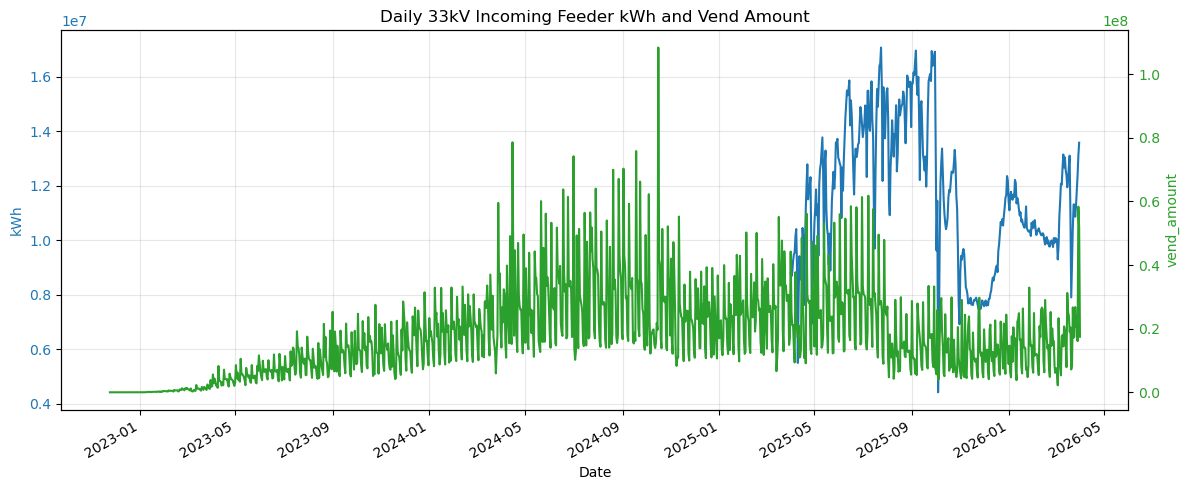

,date,kWh,vend_amount
0,2022-11-24,NaN,10.0
1,2022-11-25,NaN,10.0
2,2022-11-28,NaN,10.0
3,2022-11-29,NaN,1015.0
4,2022-11-30,NaN,1726.0


Saved daily summary workbook to: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_daily_summary.xlsx
Saved daily summary chart to: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_daily_summary.png


In [10]:
vend_daily_summary_df = (
    vend_amounts_daily.groupby("day", as_index=False)["vend_amount"]
    .sum(min_count=1)
    .rename(columns={"day": "date"})
    .sort_values("date")
    .reset_index(drop=True)
)

daily_summary_df = (
    kwh_daily_summary_df.merge(vend_daily_summary_df, on="date", how="outer")
    .sort_values("date")
    .reset_index(drop=True)
)

data_dir.mkdir(parents=True, exist_ok=True)
daily_summary_df.to_excel(summary_xlsx_path, index=False)

import matplotlib.pyplot as plt

plot_df = daily_summary_df.sort_values("date")
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(plot_df["date"], plot_df["kWh"], color="tab:blue", linewidth=1.5, label="kWh")
ax1.set_xlabel("Date")
ax1.set_ylabel("kWh", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(plot_df["date"], plot_df["vend_amount"], color="tab:green", linewidth=1.5, label="vend_amount")
ax2.set_ylabel("vend_amount", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")

ax1.set_title("Daily 33kV Incoming Feeder kWh and Vend Amount")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(summary_png_path, dpi=150, bbox_inches="tight")
plt.show()

display(daily_summary_df.head())
print(f"Saved daily summary workbook to: {summary_xlsx_path}")
print(f"Saved daily summary chart to: {summary_png_path}")

## Daily Analysis Views\n\nThese views focus on the actual feeder period from 2025-04-01 to 2026-03-31.\n\nThey add three complementary visuals:\n\n- a daily trend chart to see overall movement and seasonality\n- a weekday profile with averages and standard deviations to match the summary table pattern\n- a kWh versus vend-amount scatter plot to inspect how tightly the two measures move together\n

In [11]:
ANALYSIS_START = pd.Timestamp("2025-04-01")
ANALYSIS_END = pd.Timestamp("2026-03-31")
DAY_OF_WEEK_ORDER = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]


def coefficient_of_variation(mean_value: float, std_value: float) -> float | pd.NA:
    if pd.isna(mean_value) or pd.isna(std_value) or mean_value == 0:
        return pd.NA
    return std_value / mean_value


analysis_daily_summary_df = (
    daily_summary_df.loc[
        lambda frame: frame["date"].between(ANALYSIS_START, ANALYSIS_END, inclusive="both")
    ]
    .copy()
)
analysis_daily_summary_df["DayOfWeek"] = pd.Categorical(
    analysis_daily_summary_df["date"].dt.day_name(),
    categories=DAY_OF_WEEK_ORDER,
    ordered=True,
)
analysis_daily_summary_df["Rs/kWh"] = analysis_daily_summary_df["vend_amount"] / analysis_daily_summary_df["kWh"]
analysis_daily_summary_df.loc[
    analysis_daily_summary_df["kWh"].isna() | (analysis_daily_summary_df["kWh"] == 0),
    "Rs/kWh",
] = pd.NA

weekday_summary_df = (
    analysis_daily_summary_df.groupby("DayOfWeek", observed=False)
    .agg(
        average_kwh=("kWh", "mean"),
        stddev_kwh=("kWh", "std"),
        average_vend_amount=("vend_amount", "mean"),
        stddev_vend_amount=("vend_amount", "std"),
        average_rs_per_kwh=("Rs/kWh", "mean"),
        stddev_rs_per_kwh=("Rs/kWh", "std"),
    )
    .reset_index()
)

weekday_summary_df["cv_kwh"] = weekday_summary_df.apply(
    lambda row: coefficient_of_variation(row["average_kwh"], row["stddev_kwh"]),
    axis=1,
)
weekday_summary_df["cv_vend_amount"] = weekday_summary_df.apply(
    lambda row: coefficient_of_variation(row["average_vend_amount"], row["stddev_vend_amount"]),
    axis=1,
)
weekday_summary_df["cv_rs_per_kwh"] = weekday_summary_df.apply(
    lambda row: coefficient_of_variation(row["average_rs_per_kwh"], row["stddev_rs_per_kwh"]),
    axis=1,
)

weekday_overall_row = pd.DataFrame([
    {
        "DayOfWeek": "Overall",
        "average_kwh": analysis_daily_summary_df["kWh"].mean(),
        "stddev_kwh": analysis_daily_summary_df["kWh"].std(),
        "average_vend_amount": analysis_daily_summary_df["vend_amount"].mean(),
        "stddev_vend_amount": analysis_daily_summary_df["vend_amount"].std(),
        "average_rs_per_kwh": analysis_daily_summary_df["Rs/kWh"].mean(),
        "stddev_rs_per_kwh": analysis_daily_summary_df["Rs/kWh"].std(),
        "cv_kwh": coefficient_of_variation(analysis_daily_summary_df["kWh"].mean(), analysis_daily_summary_df["kWh"].std()),
        "cv_vend_amount": coefficient_of_variation(analysis_daily_summary_df["vend_amount"].mean(), analysis_daily_summary_df["vend_amount"].std()),
        "cv_rs_per_kwh": coefficient_of_variation(analysis_daily_summary_df["Rs/kWh"].mean(), analysis_daily_summary_df["Rs/kWh"].std()),
    }
])

weekday_summary_export_df = pd.concat([weekday_summary_df, weekday_overall_row], ignore_index=True).rename(columns={
    "average_kwh": "Average of kWh",
    "stddev_kwh": "StdDev of kWh",
    "average_vend_amount": "Average of vend_amount",
    "stddev_vend_amount": "StdDev of vend_amount",
    "average_rs_per_kwh": "Average of Rs/kWh",
    "stddev_rs_per_kwh": "StdDev of Rs/kWh",
    "cv_kwh": "CV of kWh",
    "cv_vend_amount": "CV of Rs",
    "cv_rs_per_kwh": "CV of Rs/kWh",
})

weekday_summary_export_df.to_excel(weekday_summary_xlsx_path, index=False)

display(analysis_daily_summary_df.head())
display(weekday_summary_export_df)
print(f"Saved weekday summary workbook to: {weekday_summary_xlsx_path}")

,date,kWh,vend_amount,DayOfWeek,Rs/kWh
846,2025-04-01,8.802806e+06,44222308.50,Tuesday,5.023660
847,2025-04-02,8.673005e+06,25037602.15,Wednesday,2.886843
848,2025-04-03,8.825406e+06,21047710.68,Thursday,2.384900
849,2025-04-04,9.229124e+06,21152052.50,Friday,2.291881
850,2025-04-05,9.470700e+06,14241824.25,Saturday,1.503777


,DayOfWeek,Average of kWh,StdDev of kWh,Average of vend_amount,StdDev of vend_amount,Average of Rs/kWh,StdDev of Rs/kWh,CV of kWh,CV of Rs,CV of Rs/kWh
0,Monday,1.168170e+07,2.540128e+06,3.078001e+07,1.566548e+07,2.656226,1.280735,0.217445,0.508950,0.482163
1,Tuesday,1.178185e+07,2.573307e+06,2.351481e+07,1.249039e+07,2.072796,1.160966,0.218413,0.531171,0.560097
2,Wednesday,1.164585e+07,2.453609e+06,1.989736e+07,8.525622e+06,1.745617,0.750526,0.210685,0.428480,0.429949
3,Thursday,1.159008e+07,2.613811e+06,1.853945e+07,7.982094e+06,1.618489,0.633360,0.225521,0.430546,0.391328
4,Friday,1.178114e+07,2.610837e+06,1.951735e+07,8.327925e+06,1.690799,0.683126,0.221611,0.426694,0.404026
5,Saturday,1.169846e+07,2.743752e+06,1.061720e+07,5.005672e+06,0.913577,0.380903,0.234540,0.471468,0.416936
6,Sunday,1.160826e+07,2.444689e+06,8.299721e+06,3.821874e+06,0.713127,0.282217,0.210599,0.460482,0.395746
7,Overall,1.168417e+07,2.550095e+06,1.875107e+07,1.184759e+07,1.631303,1.014512,0.218252,0.631835,0.621903


Saved weekday summary workbook to: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_weekday_summary.xlsx


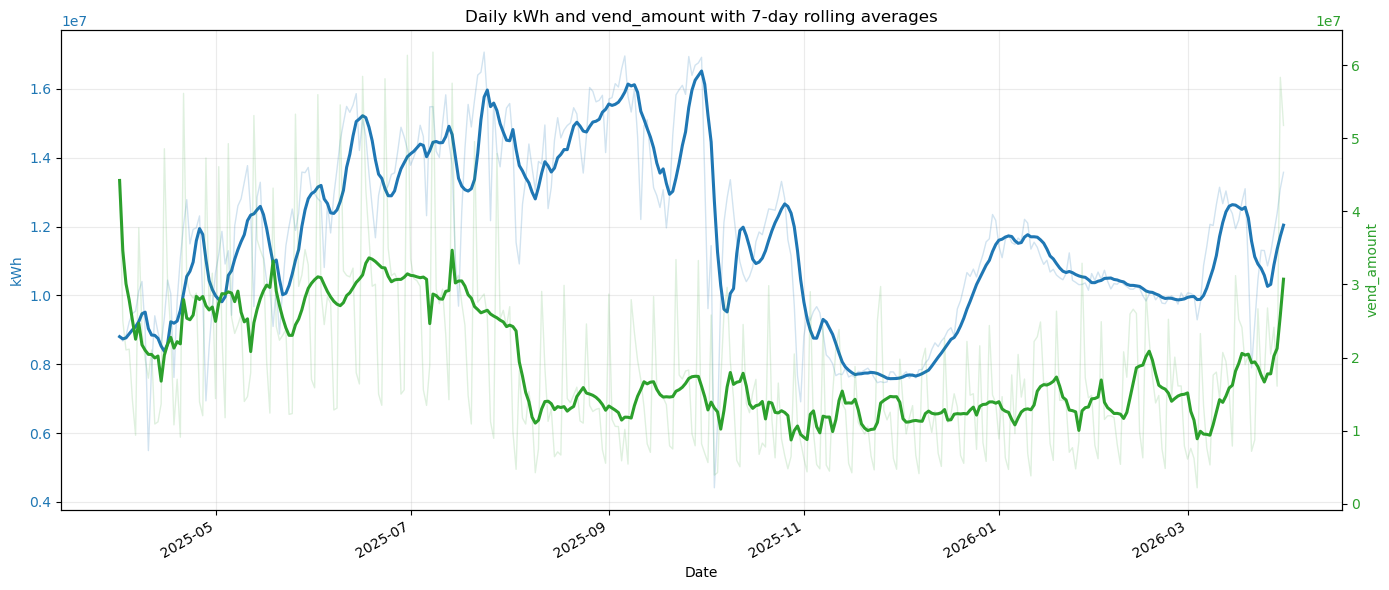

Saved trend chart to: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_kwh_vend_trend.png


In [12]:
import matplotlib.pyplot as plt

trend_df = analysis_daily_summary_df.sort_values("date").copy()
trend_df["kWh_7d_avg"] = trend_df["kWh"].rolling(window=7, min_periods=1).mean()
trend_df["vend_amount_7d_avg"] = trend_df["vend_amount"].rolling(window=7, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(trend_df["date"], trend_df["kWh"], color="tab:blue", alpha=0.2, linewidth=1)
ax1.plot(trend_df["date"], trend_df["kWh_7d_avg"], color="tab:blue", linewidth=2.2)
ax1.set_xlabel("Date")
ax1.set_ylabel("kWh", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(trend_df["date"], trend_df["vend_amount"], color="tab:green", alpha=0.15, linewidth=1)
ax2.plot(trend_df["date"], trend_df["vend_amount_7d_avg"], color="tab:green", linewidth=2.2)
ax2.set_ylabel("vend_amount", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")

ax1.set_title("Daily kWh and vend_amount with 7-day rolling averages")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(trend_png_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved trend chart to: {trend_png_path}")

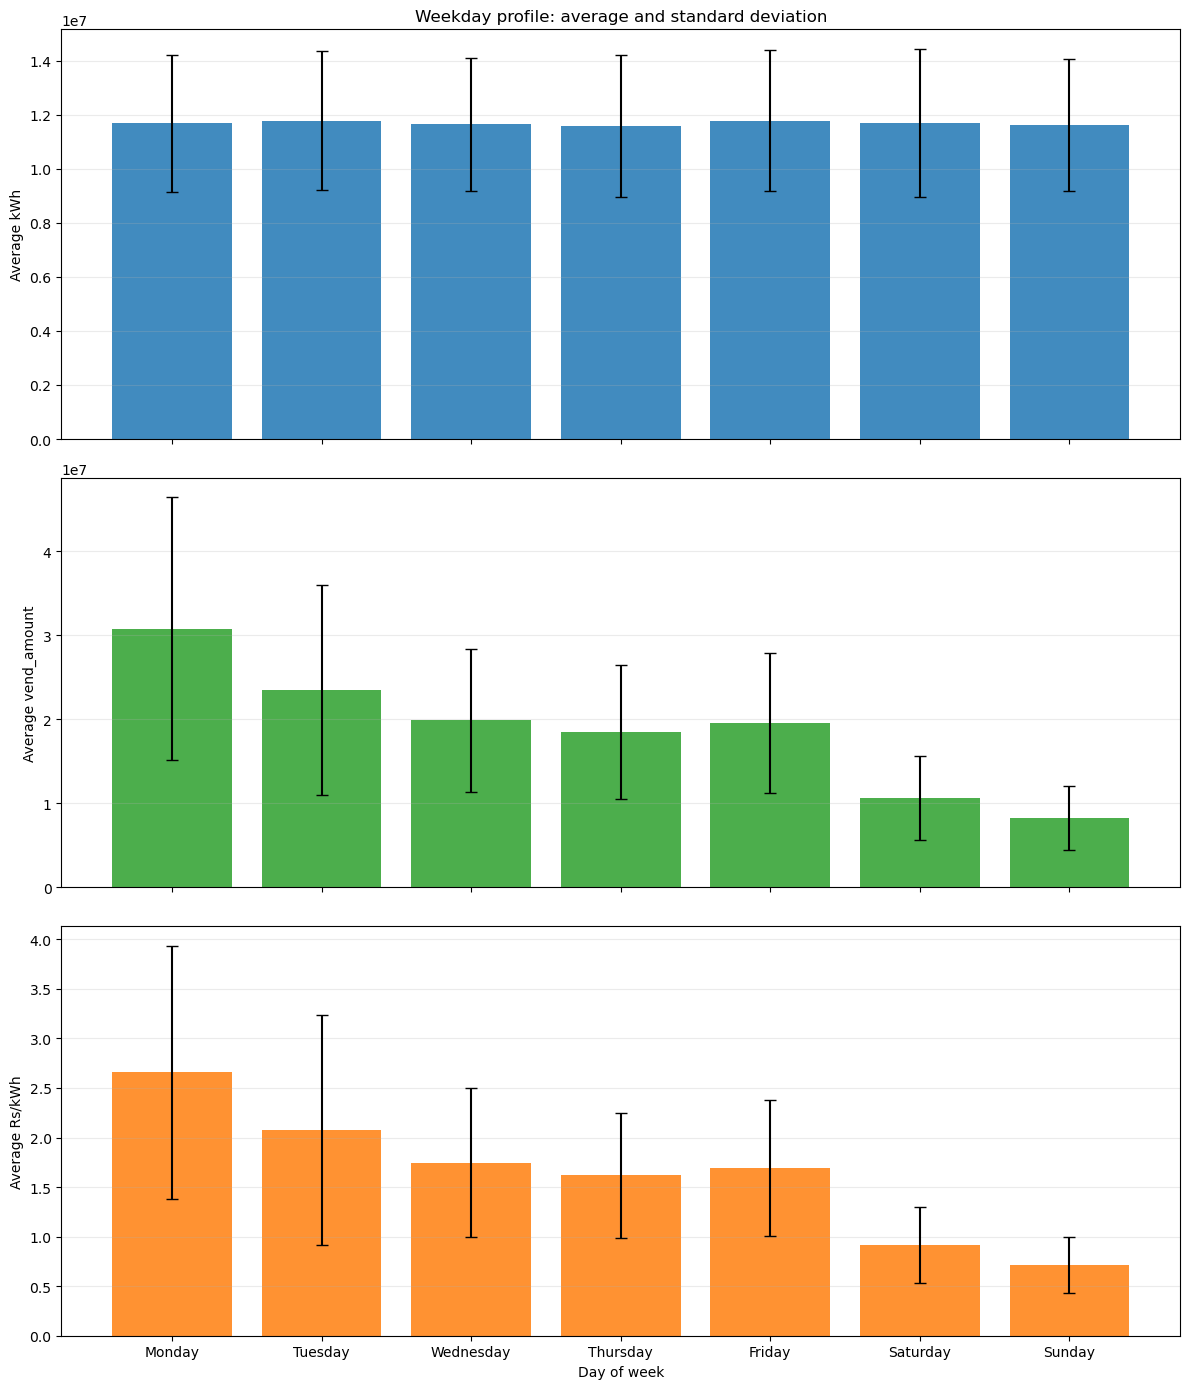

Saved weekday profile chart to: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_weekday_profile.png


In [13]:
weekday_plot_df = weekday_summary_df.copy()

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

axes[0].bar(
    weekday_plot_df["DayOfWeek"].astype(str),
    weekday_plot_df["average_kwh"],
    yerr=weekday_plot_df["stddev_kwh"],
    color="tab:blue",
    alpha=0.85,
    capsize=4,
)
axes[0].set_ylabel("Average kWh")
axes[0].set_title("Weekday profile: average and standard deviation")
axes[0].grid(True, axis="y", alpha=0.25)

axes[1].bar(
    weekday_plot_df["DayOfWeek"].astype(str),
    weekday_plot_df["average_vend_amount"],
    yerr=weekday_plot_df["stddev_vend_amount"],
    color="tab:green",
    alpha=0.85,
    capsize=4,
)
axes[1].set_ylabel("Average vend_amount")
axes[1].grid(True, axis="y", alpha=0.25)

axes[2].bar(
    weekday_plot_df["DayOfWeek"].astype(str),
    weekday_plot_df["average_rs_per_kwh"],
    yerr=weekday_plot_df["stddev_rs_per_kwh"],
    color="tab:orange",
    alpha=0.85,
    capsize=4,
)
axes[2].set_ylabel("Average Rs/kWh")
axes[2].set_xlabel("Day of week")
axes[2].grid(True, axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(weekday_profile_png_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved weekday profile chart to: {weekday_profile_png_path}")

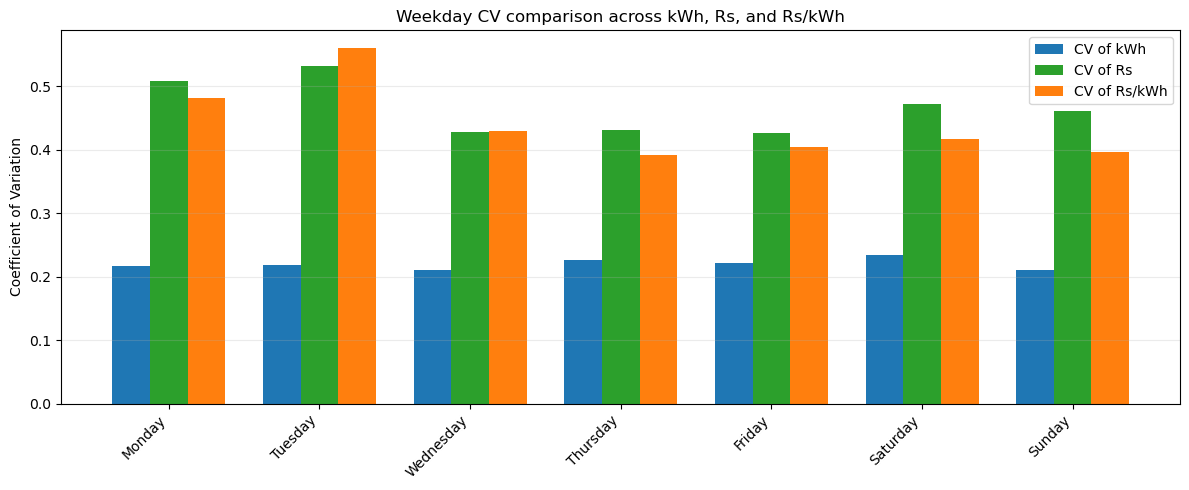

Saved weekday CV chart to: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_weekday_cv_comparison.png


In [14]:
import numpy as np

weekday_cv_plot_df = weekday_summary_export_df.loc[
    weekday_summary_export_df["DayOfWeek"] != "Overall",
    ["DayOfWeek", "CV of kWh", "CV of Rs", "CV of Rs/kWh"],
].copy()

x = np.arange(len(weekday_cv_plot_df))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - bar_width, weekday_cv_plot_df["CV of kWh"], width=bar_width, color="tab:blue", label="CV of kWh")
ax.bar(x, weekday_cv_plot_df["CV of Rs"], width=bar_width, color="tab:green", label="CV of Rs")
ax.bar(x + bar_width, weekday_cv_plot_df["CV of Rs/kWh"], width=bar_width, color="tab:orange", label="CV of Rs/kWh")
ax.set_xticks(x)
ax.set_xticklabels(weekday_cv_plot_df["DayOfWeek"], rotation=45, ha="right")
ax.set_ylabel("Coefficient of Variation")
ax.set_title("Weekday CV comparison across kWh, Rs, and Rs/kWh")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(weekday_cv_png_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved weekday CV chart to: {weekday_cv_png_path}")

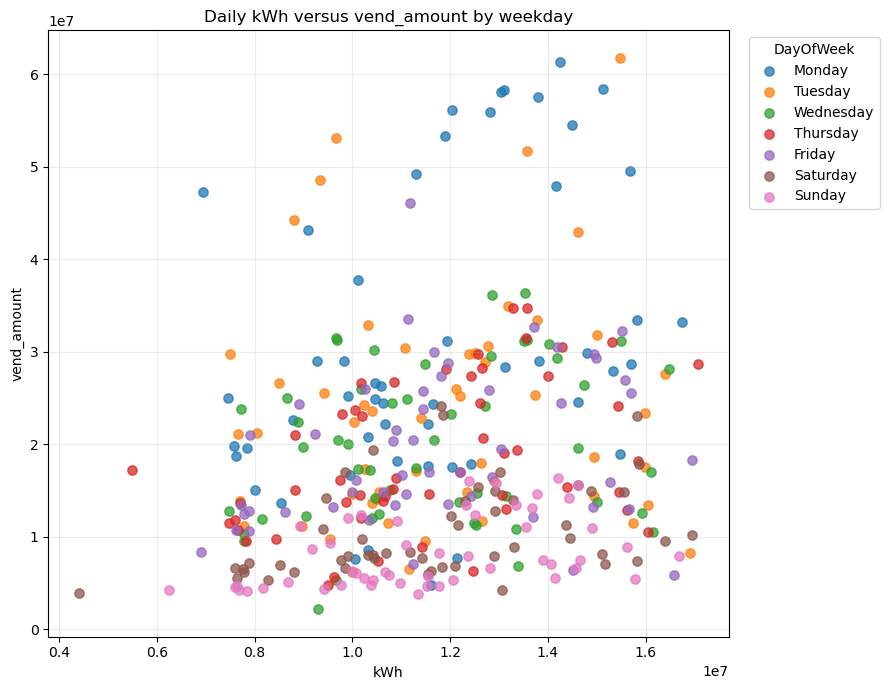

Saved scatter chart to: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_kwh_vs_vend_scatter.png


In [15]:
scatter_df = analysis_daily_summary_df.dropna(subset=["kWh", "vend_amount", "DayOfWeek"]).copy()
weekday_palette = {
    "Monday": "tab:blue",
    "Tuesday": "tab:orange",
    "Wednesday": "tab:green",
    "Thursday": "tab:red",
    "Friday": "tab:purple",
    "Saturday": "tab:brown",
    "Sunday": "tab:pink",
}

fig, ax = plt.subplots(figsize=(9, 7))
for day_name in DAY_OF_WEEK_ORDER:
    subset = scatter_df.loc[scatter_df["DayOfWeek"] == day_name]
    if subset.empty:
        continue
    ax.scatter(
        subset["kWh"],
        subset["vend_amount"],
        s=45,
        alpha=0.75,
        label=day_name,
        color=weekday_palette[day_name],
    )

ax.set_title("Daily kWh versus vend_amount by weekday")
ax.set_xlabel("kWh")
ax.set_ylabel("vend_amount")
ax.grid(True, alpha=0.25)
ax.legend(title="DayOfWeek", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(scatter_png_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved scatter chart to: {scatter_png_path}")

## Alternative Visuals\n\nThese are cleaner alternatives to distribution-heavy plots.\n\n- monthly totals show the broad seasonality clearly\n- an indexed trend compares movement in kWh and 
end_amount on the same scale\n- a month-by-weekday heatmap surfaces operational rhythm without clutter\n

In [16]:
analysis_daily_summary_df["MonthStart"] = analysis_daily_summary_df["date"].dt.to_period("M").dt.to_timestamp()
analysis_daily_summary_df["MonthLabel"] = analysis_daily_summary_df["MonthStart"].dt.strftime("%b-%Y")

monthly_summary_df = (
    analysis_daily_summary_df.groupby(["MonthStart", "MonthLabel"], as_index=False)
    .agg(
        kWh=("kWh", "sum"),
        vend_amount=("vend_amount", "sum"),
        rs_per_kwh=("Rs/kWh", "mean"),
    )
    .sort_values("MonthStart")
    .reset_index(drop=True)
)

display(monthly_summary_df)

,MonthStart,MonthLabel,kWh,vend_amount,rs_per_kwh
0,2025-04-01,Apr-2025,2.902686e+08,7.336003e+08,2.579520
1,2025-05-01,May-2025,3.623613e+08,8.396620e+08,2.369227
2,2025-06-01,Jun-2025,4.113083e+08,9.266082e+08,2.260397
3,2025-07-01,Jul-2025,4.472602e+08,8.581802e+08,1.943460
4,2025-08-01,Aug-2025,4.435025e+08,4.147041e+08,0.935637
5,2025-09-01,Sep-2025,4.538198e+08,4.655502e+08,1.036882
6,2025-10-01,Oct-2025,3.415754e+08,4.000345e+08,1.169345
7,2025-11-01,Nov-2025,2.432663e+08,3.641440e+08,1.518247
8,2025-12-01,Dec-2025,2.897711e+08,4.013064e+08,1.409376
9,2026-01-01,Jan-2026,3.417395e+08,4.258074e+08,1.251917


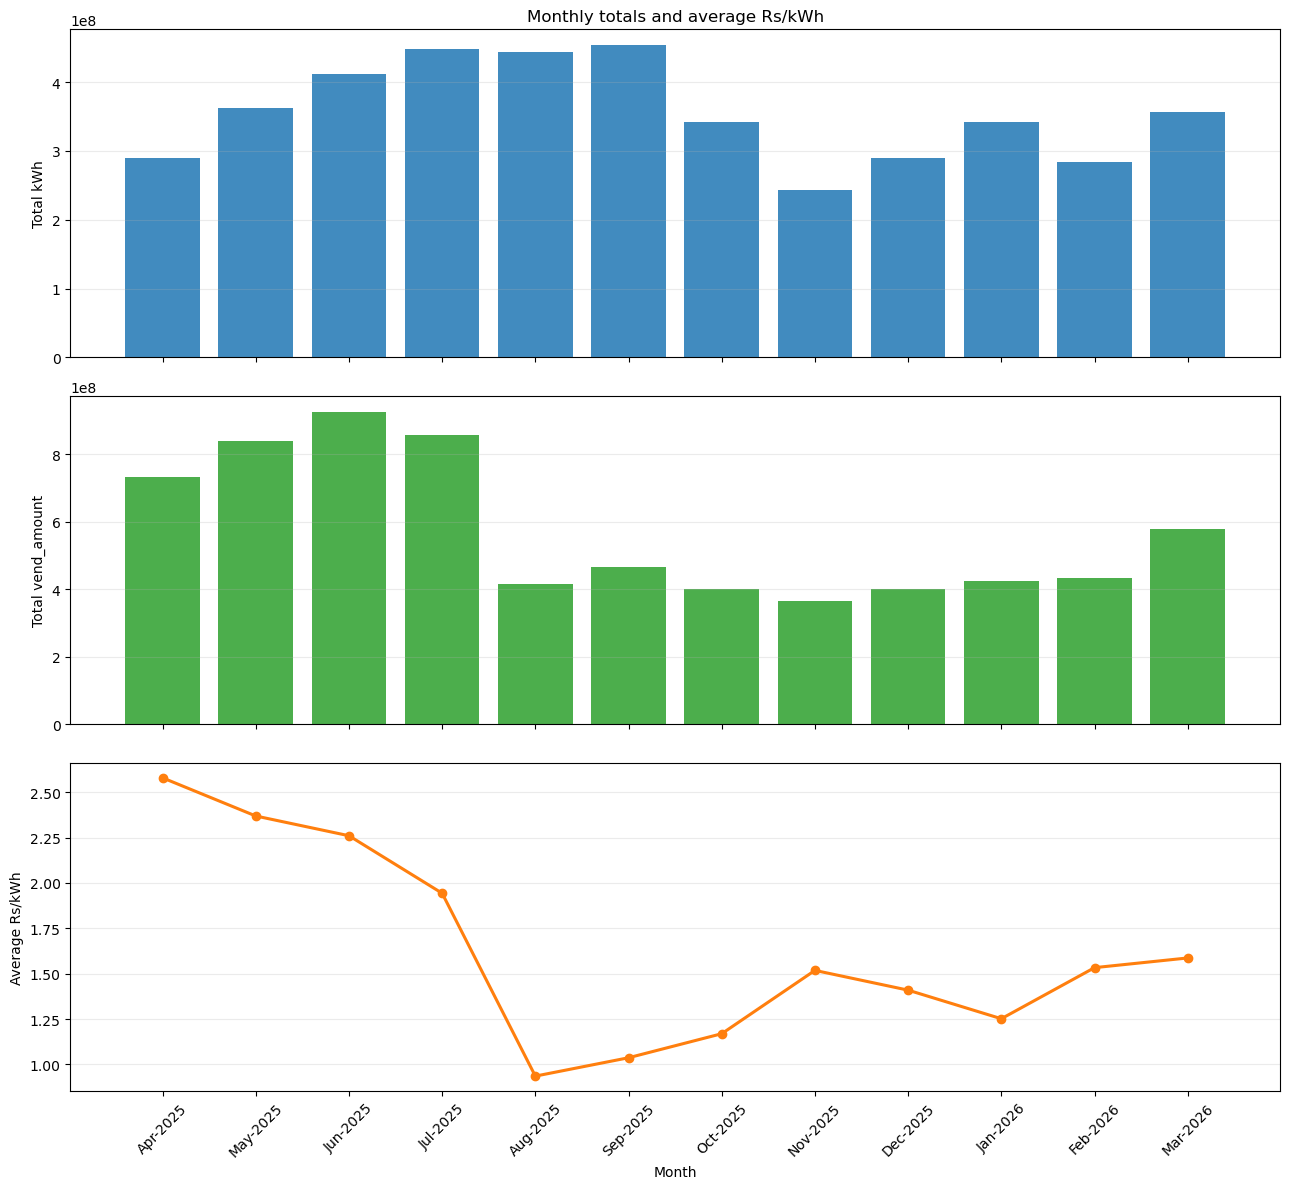

Saved monthly profile chart to: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_monthly_profile.png


In [17]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

axes[0].bar(monthly_summary_df["MonthLabel"], monthly_summary_df["kWh"], color="tab:blue", alpha=0.85)
axes[0].set_ylabel("Total kWh")
axes[0].set_title("Monthly totals and average Rs/kWh")
axes[0].grid(True, axis="y", alpha=0.25)

axes[1].bar(monthly_summary_df["MonthLabel"], monthly_summary_df["vend_amount"], color="tab:green", alpha=0.85)
axes[1].set_ylabel("Total vend_amount")
axes[1].grid(True, axis="y", alpha=0.25)

axes[2].plot(monthly_summary_df["MonthLabel"], monthly_summary_df["rs_per_kwh"], color="tab:orange", linewidth=2.2, marker="o")
axes[2].set_ylabel("Average Rs/kWh")
axes[2].set_xlabel("Month")
axes[2].grid(True, axis="y", alpha=0.25)

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(monthly_profile_png_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved monthly profile chart to: {monthly_profile_png_path}")

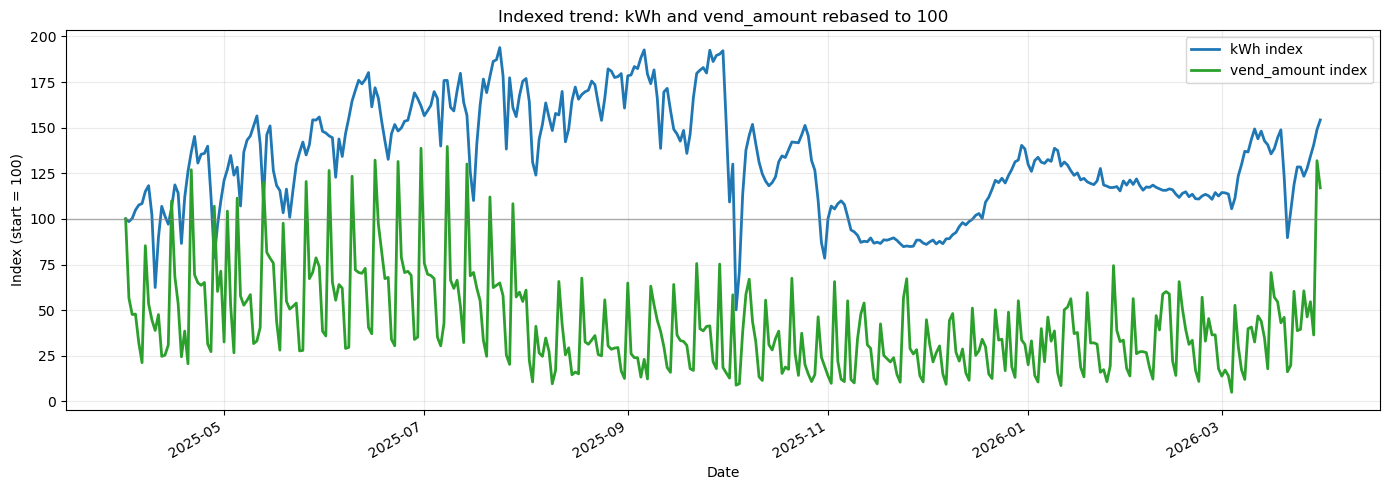

Saved indexed trend chart to: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_indexed_trend.png


In [18]:
indexed_plot_df = analysis_daily_summary_df.sort_values("date").copy()
first_kwh = indexed_plot_df["kWh"].dropna().iloc[0]
first_vend_amount = indexed_plot_df["vend_amount"].dropna().iloc[0]

indexed_plot_df["kWh_index_100"] = indexed_plot_df["kWh"] / first_kwh * 100
indexed_plot_df["vend_amount_index_100"] = indexed_plot_df["vend_amount"] / first_vend_amount * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(indexed_plot_df["date"], indexed_plot_df["kWh_index_100"], color="tab:blue", linewidth=2, label="kWh index")
ax.plot(indexed_plot_df["date"], indexed_plot_df["vend_amount_index_100"], color="tab:green", linewidth=2, label="vend_amount index")
ax.axhline(100, color="grey", linewidth=1, alpha=0.6)
ax.set_title("Indexed trend: kWh and vend_amount rebased to 100")
ax.set_xlabel("Date")
ax.set_ylabel("Index (start = 100)")
ax.grid(True, alpha=0.25)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(indexed_trend_png_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved indexed trend chart to: {indexed_trend_png_path}")

C:\Users\ronny\AppData\Local\Temp\ipykernel_46360\4017980068.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  kwh_heatmap_df = heatmap_base_df.pivot_table(
C:\Users\ronny\AppData\Local\Temp\ipykernel_46360\4017980068.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  vend_heatmap_df = heatmap_base_df.pivot_table(


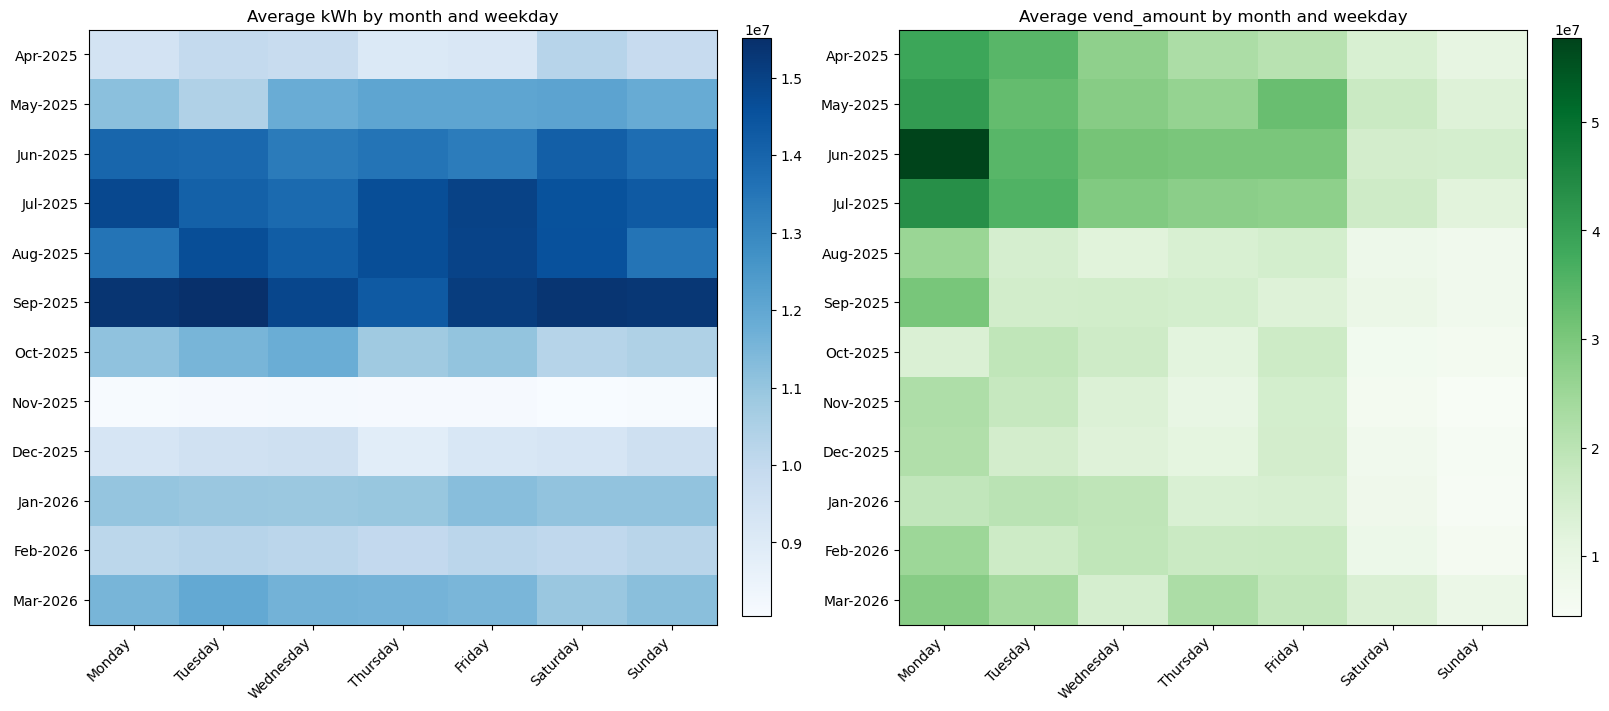

Saved heatmap chart to: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_weekday_month_heatmap.png


In [19]:
heatmap_base_df = analysis_daily_summary_df.copy()
heatmap_base_df["MonthLabel"] = pd.Categorical(
    heatmap_base_df["MonthStart"].dt.strftime("%b-%Y"),
    categories=monthly_summary_df["MonthLabel"].tolist(),
    ordered=True,
)

kwh_heatmap_df = heatmap_base_df.pivot_table(
    index="MonthLabel",
    columns="DayOfWeek",
    values="kWh",
    aggfunc="mean",
).reindex(columns=DAY_OF_WEEK_ORDER)

vend_heatmap_df = heatmap_base_df.pivot_table(
    index="MonthLabel",
    columns="DayOfWeek",
    values="vend_amount",
    aggfunc="mean",
).reindex(columns=DAY_OF_WEEK_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

im1 = axes[0].imshow(kwh_heatmap_df.to_numpy(), aspect="auto", cmap="Blues")
axes[0].set_title("Average kWh by month and weekday")
axes[0].set_xticks(range(len(DAY_OF_WEEK_ORDER)))
axes[0].set_xticklabels(DAY_OF_WEEK_ORDER, rotation=45, ha="right")
axes[0].set_yticks(range(len(kwh_heatmap_df.index)))
axes[0].set_yticklabels(kwh_heatmap_df.index.astype(str))
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(vend_heatmap_df.to_numpy(), aspect="auto", cmap="Greens")
axes[1].set_title("Average vend_amount by month and weekday")
axes[1].set_xticks(range(len(DAY_OF_WEEK_ORDER)))
axes[1].set_xticklabels(DAY_OF_WEEK_ORDER, rotation=45, ha="right")
axes[1].set_yticks(range(len(vend_heatmap_df.index)))
axes[1].set_yticklabels(vend_heatmap_df.index.astype(str))
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

fig.savefig(heatmap_png_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved heatmap chart to: {heatmap_png_path}")

## Boxplots And Holiday-Based Grouping\n\nThese views keep the full distribution information in the notebook instead of replacing it.\n\nThe Bihar holiday dates below are a practical analysis calendar based on published Bihar holiday lists for 2025 and 2026.\nMoon-sighting holidays can shift, so this should be treated as an operational grouping aid rather than a legal holiday register.\n

In [20]:
BIHAR_PUBLIC_HOLIDAYS = [
    ("2025-04-06", "Ram Navami"),
    ("2025-04-13", "Maha Vishuba Sankranti"),
    ("2025-04-14", "Dr Ambedkar Jayanti"),
    ("2025-04-18", "Good Friday"),
    ("2025-05-01", "May Day"),
    ("2025-06-07", "Bakrid / Eid al Adha"),
    ("2025-07-06", "Muharram"),
    ("2025-08-08", "Jhulan Purnima"),
    ("2025-08-15", "Independence Day"),
    ("2025-08-16", "Janmashtami"),
    ("2025-10-01", "Maha Navami"),
    ("2025-10-02", "Vijaya Dashami / Gandhi Jayanti"),
    ("2025-10-20", "Diwali"),
    ("2025-10-27", "Chhath Puja"),
    ("2025-10-28", "Chhath Puja Holiday"),
    ("2025-12-25", "Christmas Day"),
    ("2026-01-26", "Republic Day"),
    ("2026-03-03", "Holi"),
    ("2026-03-21", "Idul Fitr"),
    ("2026-03-22", "Bihar Day"),
    ("2026-03-27", "Ram Navami"),
]

bihar_public_holidays_df = pd.DataFrame(BIHAR_PUBLIC_HOLIDAYS, columns=["holiday_date", "holiday_name"])
bihar_public_holidays_df["holiday_date"] = pd.to_datetime(bihar_public_holidays_df["holiday_date"])
bihar_public_holidays_df = bihar_public_holidays_df.loc[
    lambda frame: frame["holiday_date"].between(ANALYSIS_START, ANALYSIS_END, inclusive="both")
].sort_values("holiday_date").reset_index(drop=True)

holiday_dates = set(bihar_public_holidays_df["holiday_date"])
day_after_holiday_dates = {holiday_date + pd.Timedelta(days=1) for holiday_date in holiday_dates}

analysis_daily_summary_df["is_public_holiday"] = analysis_daily_summary_df["date"].isin(holiday_dates)
analysis_daily_summary_df["is_weekend"] = analysis_daily_summary_df["DayOfWeek"].isin(["Saturday", "Sunday"])
analysis_daily_summary_df["is_weekday_public_holiday"] = (
    analysis_daily_summary_df["is_public_holiday"]
    & ~analysis_daily_summary_df["is_weekend"]
)
analysis_daily_summary_df["is_weekday_after_public_holiday"] = (
    analysis_daily_summary_df["date"].isin(day_after_holiday_dates)
    & ~analysis_daily_summary_df["is_weekend"]
)
analysis_daily_summary_df["is_monday_excluding_public_holiday_and_day_after_public_holiday"] = (
    analysis_daily_summary_df["DayOfWeek"].eq("Monday")
    & ~analysis_daily_summary_df["is_weekday_public_holiday"]
    & ~analysis_daily_summary_df["is_weekday_after_public_holiday"]
)
analysis_daily_summary_df["is_tue_thu_excluding_public_holiday_and_day_after_public_holiday"] = (
    analysis_daily_summary_df["DayOfWeek"].isin(["Tuesday", "Wednesday", "Thursday"])
    & ~analysis_daily_summary_df["is_weekday_public_holiday"]
    & ~analysis_daily_summary_df["is_weekday_after_public_holiday"]
)
analysis_daily_summary_df["is_friday_excluding_public_holiday_and_day_after_public_holiday"] = (
    analysis_daily_summary_df["DayOfWeek"].eq("Friday")
    & ~analysis_daily_summary_df["is_weekday_public_holiday"]
    & ~analysis_daily_summary_df["is_weekday_after_public_holiday"]
)

special_day_group_masks = {
    "Weekends": analysis_daily_summary_df["is_weekend"],
    "Weekday Public Holiday": analysis_daily_summary_df["is_weekday_public_holiday"],
    "Weekday After Public Holiday": analysis_daily_summary_df["is_weekday_after_public_holiday"],
    "Mon ex PH & daPH": analysis_daily_summary_df["is_monday_excluding_public_holiday_and_day_after_public_holiday"],
    "Tue-Thu ex PH & daPH": analysis_daily_summary_df["is_tue_thu_excluding_public_holiday_and_day_after_public_holiday"],
    "Fri ex PH & daPH": analysis_daily_summary_df["is_friday_excluding_public_holiday_and_day_after_public_holiday"],
}

special_day_summary_rows = [
    {
        "analysis_group": "Overall",
        "day_count": len(analysis_daily_summary_df),
        "average_kWh": analysis_daily_summary_df["kWh"].mean(),
        "stddev_kWh": analysis_daily_summary_df["kWh"].std(),
        "average_vend_amount": analysis_daily_summary_df["vend_amount"].mean(),
        "stddev_vend_amount": analysis_daily_summary_df["vend_amount"].std(),
        "average_rs_per_kwh": analysis_daily_summary_df["Rs/kWh"].mean(),
        "stddev_rs_per_kwh": analysis_daily_summary_df["Rs/kWh"].std(),
        "cv_kWh": coefficient_of_variation(analysis_daily_summary_df["kWh"].mean(), analysis_daily_summary_df["kWh"].std()),
        "cv_vend_amount": coefficient_of_variation(analysis_daily_summary_df["vend_amount"].mean(), analysis_daily_summary_df["vend_amount"].std()),
        "cv_rs_per_kwh": coefficient_of_variation(analysis_daily_summary_df["Rs/kWh"].mean(), analysis_daily_summary_df["Rs/kWh"].std()),
    }
]
special_day_plot_frames = []
for group_name, mask in special_day_group_masks.items():
    subset = analysis_daily_summary_df.loc[mask].copy()
    subset["analysis_group"] = group_name
    special_day_plot_frames.append(subset)
    special_day_summary_rows.append({
        "analysis_group": group_name,
        "day_count": len(subset),
        "average_kWh": subset["kWh"].mean(),
        "stddev_kWh": subset["kWh"].std(),
        "average_vend_amount": subset["vend_amount"].mean(),
        "stddev_vend_amount": subset["vend_amount"].std(),
        "average_rs_per_kwh": subset["Rs/kWh"].mean(),
        "stddev_rs_per_kwh": subset["Rs/kWh"].std(),
        "cv_kWh": coefficient_of_variation(subset["kWh"].mean(), subset["kWh"].std()),
        "cv_vend_amount": coefficient_of_variation(subset["vend_amount"].mean(), subset["vend_amount"].std()),
        "cv_rs_per_kwh": coefficient_of_variation(subset["Rs/kWh"].mean(), subset["Rs/kWh"].std()),
    })

special_day_summary_df = pd.DataFrame(special_day_summary_rows)
special_day_plot_df = pd.concat(special_day_plot_frames, ignore_index=True)

special_day_summary_export_df = special_day_summary_df.rename(columns={
    "average_kWh": "Average of kWh",
    "stddev_kWh": "StdDev of kWh",
    "average_vend_amount": "Average of vend_amount",
    "stddev_vend_amount": "StdDev of vend_amount",
    "average_rs_per_kwh": "Average of Rs/kWh",
    "stddev_rs_per_kwh": "StdDev of Rs/kWh",
    "cv_kWh": "CV of kWh",
    "cv_vend_amount": "CV of Rs",
    "cv_rs_per_kwh": "CV of Rs/kWh",
})

with pd.ExcelWriter(special_day_summary_xlsx_path) as writer:
    special_day_summary_export_df.to_excel(writer, sheet_name="special_day_summary", index=False)
    bihar_public_holidays_df.to_excel(writer, sheet_name="bihar_public_holidays", index=False)

display(bihar_public_holidays_df)
display(special_day_summary_export_df)
print(f"Saved special day summary workbook to: {special_day_summary_xlsx_path}")

,holiday_date,holiday_name
0,2025-04-06,Ram Navami
1,2025-04-13,Maha Vishuba Sankranti
2,2025-04-14,Dr Ambedkar Jayanti
3,2025-04-18,Good Friday
4,2025-05-01,May Day
5,2025-06-07,Bakrid / Eid al Adha
6,2025-07-06,Muharram
7,2025-08-08,Jhulan Purnima
8,2025-08-15,Independence Day
9,2025-08-16,Janmashtami


,analysis_group,day_count,Average of kWh,StdDev of kWh,Average of vend_amount,StdDev of vend_amount,Average of Rs/kWh,StdDev of Rs/kWh,CV of kWh,CV of Rs,CV of Rs/kWh
0,Overall,365,1.168417e+07,2.550095e+06,1.875107e+07,1.184759e+07,1.631303,1.014512,0.218252,0.631835,0.621903
1,Weekends,104,1.165336e+07,2.586279e+06,9.458460e+06,4.582020e+06,0.813352,0.348452,0.221934,0.484436,0.428414
2,Weekday Public Holiday,14,1.107528e+07,1.924707e+06,9.407320e+06,4.396457e+06,0.886403,0.462897,0.173784,0.467344,0.522219
3,Weekday After Public Holiday,14,1.071975e+07,1.716537e+06,2.404620e+07,1.434233e+07,2.267519,1.428203,0.160129,0.596449,0.629853
4,Mon ex PH & daPH,45,1.175059e+07,2.605031e+06,3.294329e+07,1.515687e+07,2.825366,1.221079,0.221694,0.460090,0.432184
5,Tue-Thu ex PH & daPH,146,1.175455e+07,2.586186e+06,2.098579e+07,9.597936e+06,1.830924,0.835491,0.220016,0.457354,0.456322
6,Fri ex PH & daPH,45,1.182271e+07,2.686504e+06,1.936757e+07,7.510684e+06,1.666525,0.586908,0.227233,0.387797,0.352175


Saved special day summary workbook to: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_special_day_summary.xlsx


C:\Users\ronny\AppData\Local\Temp\ipykernel_46360\1250655408.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\ronny\AppData\Local\Temp\ipykernel_46360\1250655408.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\ronny\AppData\Local\Temp\ipykernel_46360\1250655408.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


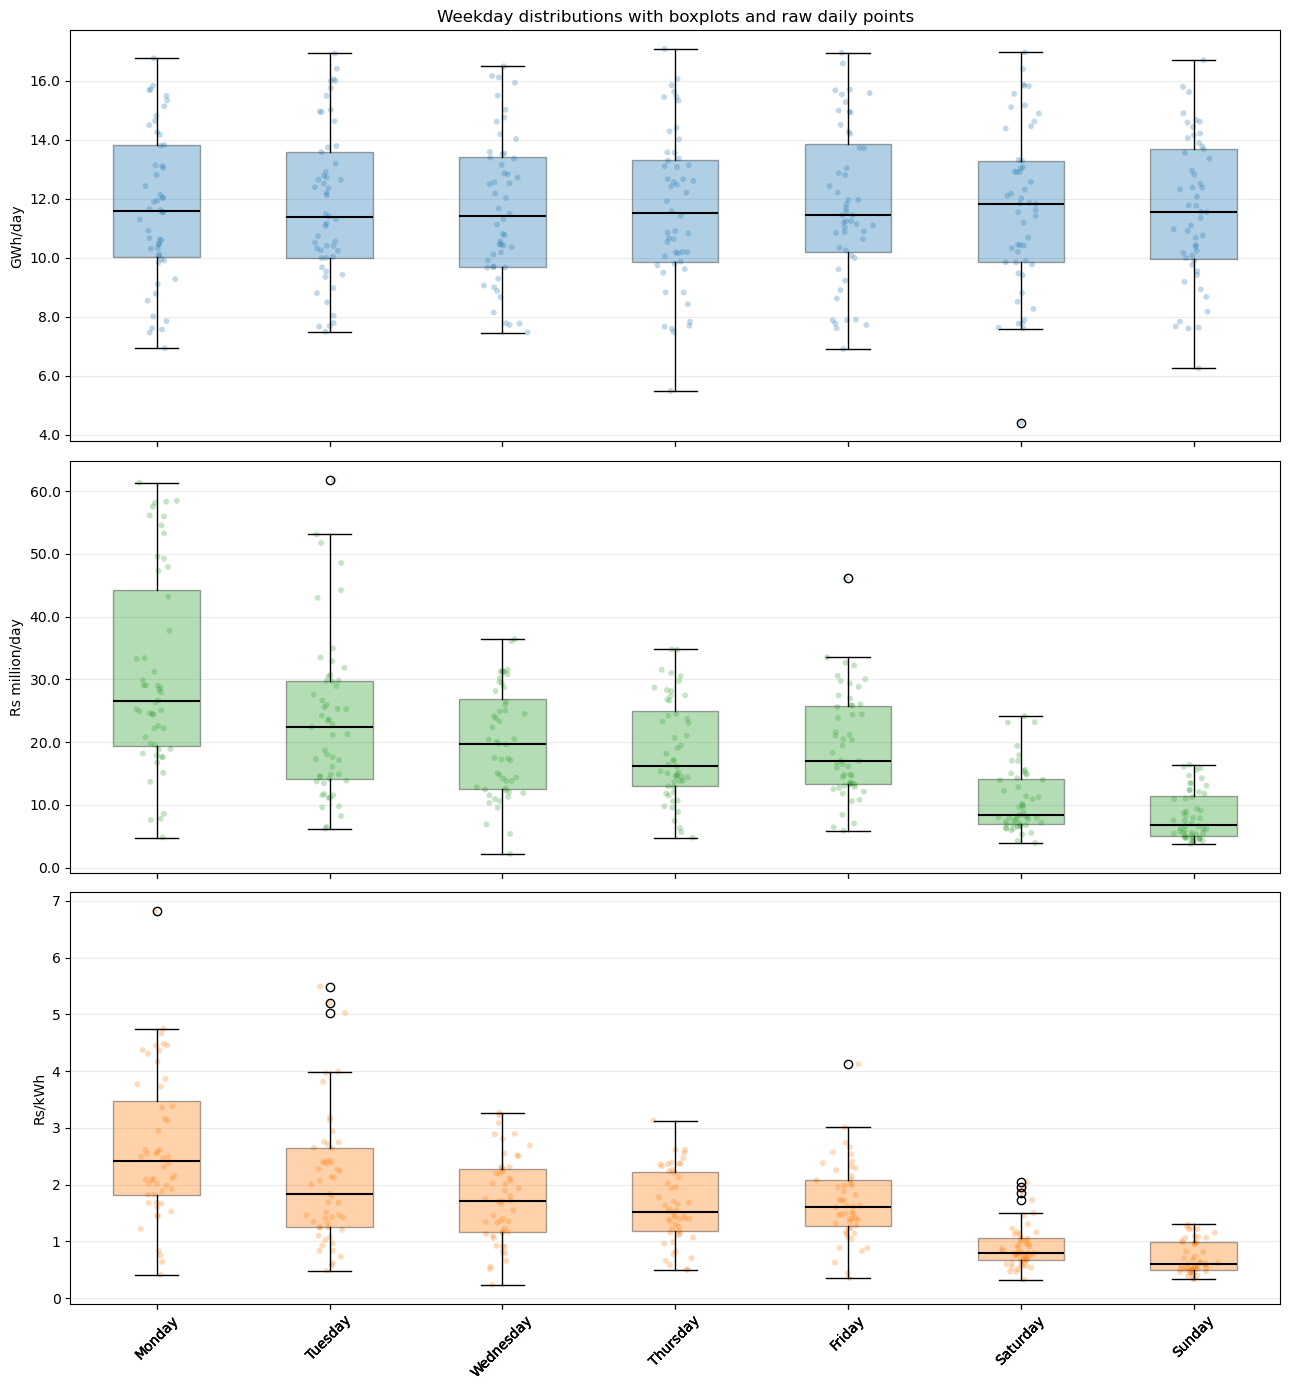

Saved weekday boxplot chart to: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_weekday_boxplots.png


In [21]:
import numpy as np

weekday_boxplot_order = DAY_OF_WEEK_ORDER
weekday_boxplot_df = analysis_daily_summary_df.dropna(subset=["DayOfWeek", "kWh", "vend_amount", "Rs/kWh"]).copy()
weekday_boxplot_df["DayOfWeek"] = pd.Categorical(
    weekday_boxplot_df["DayOfWeek"],
    categories=weekday_boxplot_order,
    ordered=True,
)

from matplotlib.ticker import FuncFormatter

def gwh_day_formatter(value, _):
    return f"{value / 1_000_000:,.1f}"

def rs_million_day_formatter(value, _):
    return f"{value / 1_000_000:,.1f}"

plot_specs = [
    ("kWh", "GWh/day", "tab:blue", gwh_day_formatter),
    ("vend_amount", "Rs million/day", "tab:green", rs_million_day_formatter),
    ("Rs/kWh", "Rs/kWh", "tab:orange", None),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 14), sharex=True)
rng = np.random.default_rng(42)

for ax, (column_name, y_label, color_name, y_formatter) in zip(axes, plot_specs):
    series_list = [
        weekday_boxplot_df.loc[weekday_boxplot_df["DayOfWeek"] == day_name, column_name].dropna().to_numpy()
        for day_name in weekday_boxplot_order
    ]
    ax.boxplot(
        series_list,
        labels=weekday_boxplot_order,
        patch_artist=True,
        boxprops={"facecolor": color_name, "alpha": 0.35},
        medianprops={"color": "black", "linewidth": 1.5},
    )
    for position, values in enumerate(series_list, start=1):
        if len(values) == 0:
            continue
        jitter = rng.normal(0, 0.05, size=len(values))
        ax.scatter(
            np.full(len(values), position) + jitter,
            values,
            s=18,
            alpha=0.28,
            color=color_name,
            edgecolors="none",
        )
    ax.set_ylabel(y_label)
    if y_formatter is not None:
        ax.yaxis.set_major_formatter(FuncFormatter(y_formatter))
    ax.grid(True, axis="y", alpha=0.25)

axes[0].set_title("Weekday distributions with boxplots and raw daily points")
axes[-1].tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(weekday_boxplot_png_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved weekday boxplot chart to: {weekday_boxplot_png_path}")

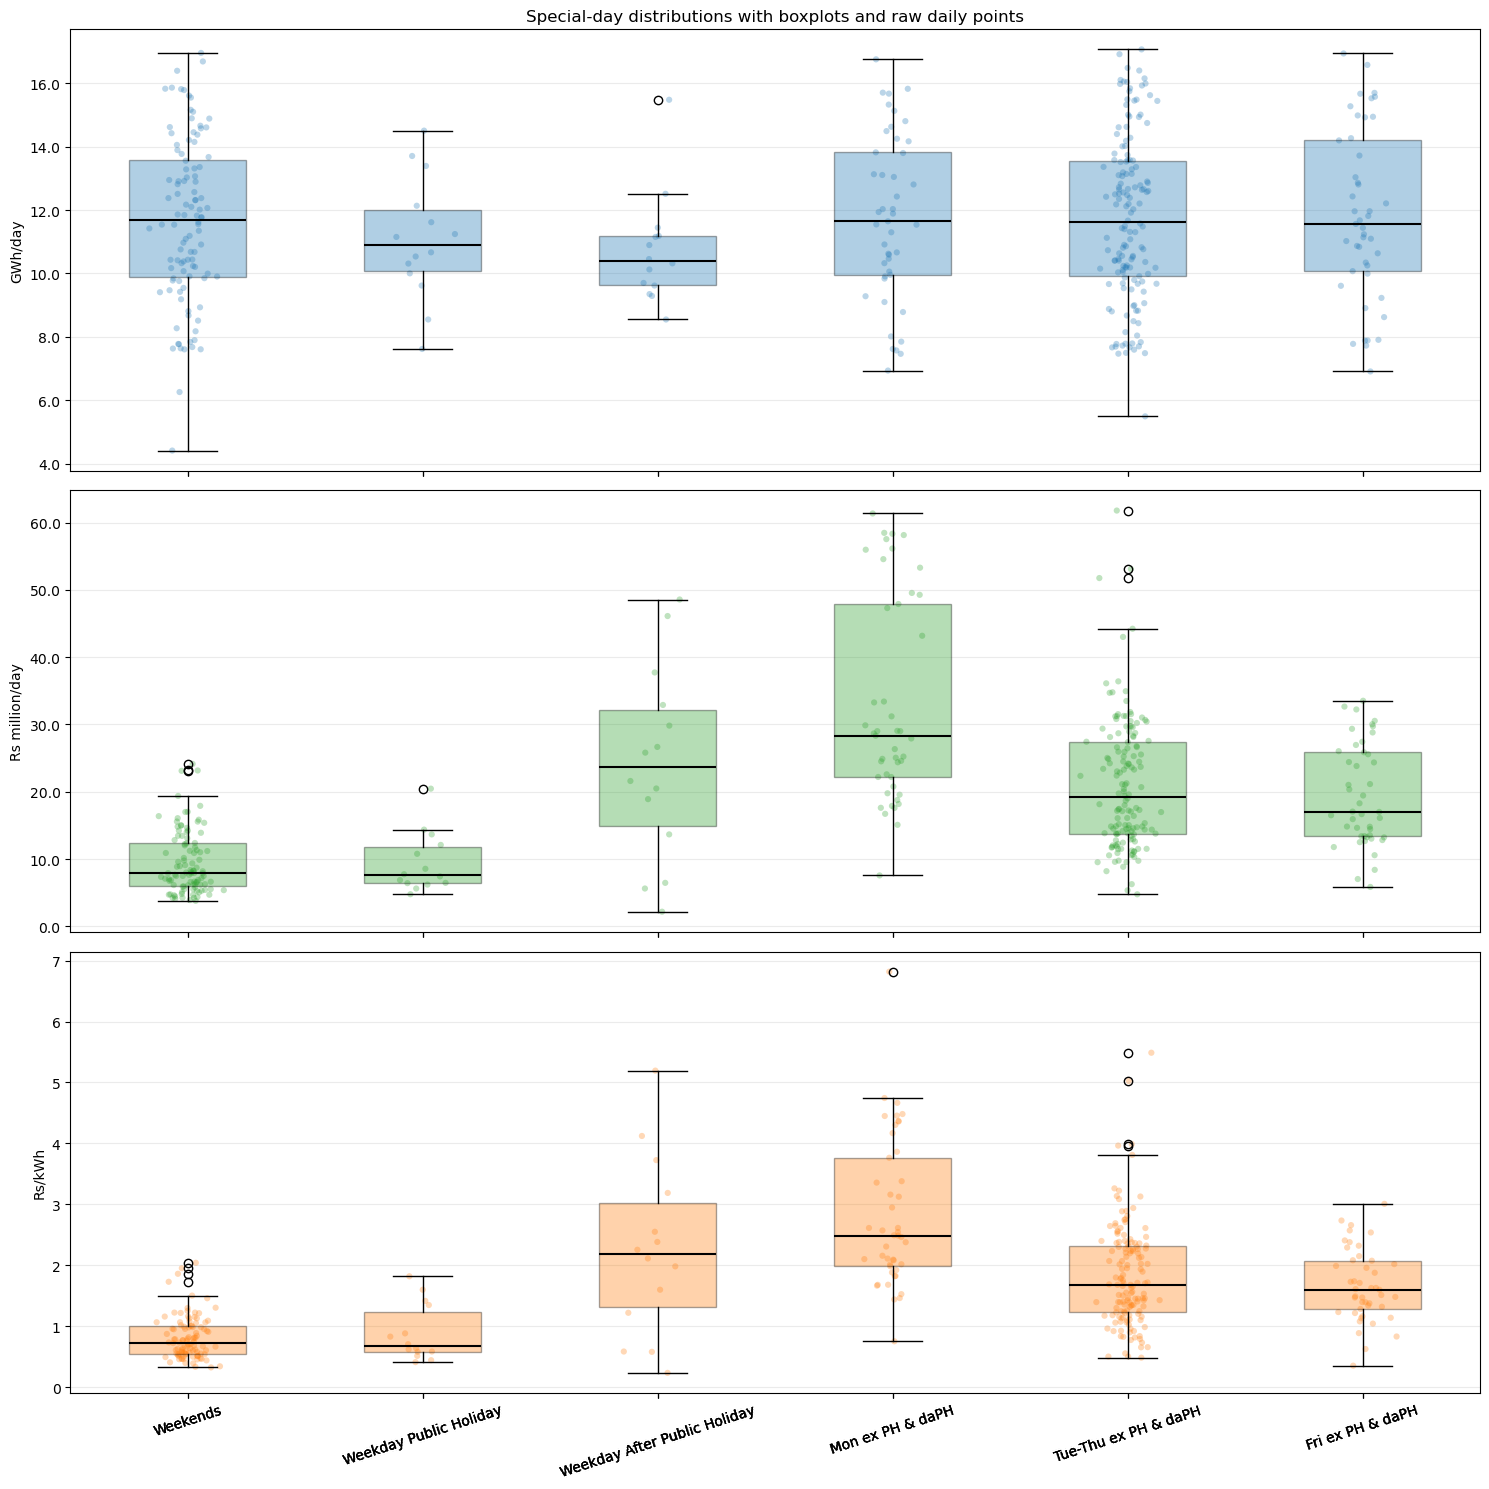

Saved special day boxplot chart to: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_special_day_boxplots.png


In [22]:
special_group_order = [
    "Weekends",
    "Weekday Public Holiday",
    "Weekday After Public Holiday",
    "Mon ex PH & daPH",
    "Tue-Thu ex PH & daPH",
    "Fri ex PH & daPH",
]

special_group_boxplot_df = special_day_plot_df.dropna(subset=["analysis_group", "kWh", "vend_amount", "Rs/kWh"]).copy()
special_group_boxplot_df["analysis_group"] = pd.Categorical(
    special_group_boxplot_df["analysis_group"],
    categories=special_group_order,
    ordered=True,
)

fig, axes = plt.subplots(3, 1, figsize=(15, 15), sharex=True)
rng = np.random.default_rng(84)

for ax, (column_name, y_label, color_name, y_formatter) in zip(axes, plot_specs):
    series_list = [
        special_group_boxplot_df.loc[special_group_boxplot_df["analysis_group"] == group_name, column_name].dropna().to_numpy()
        for group_name in special_group_order
    ]
    ax.boxplot(
        series_list,
        tick_labels=special_group_order,
        patch_artist=True,
        boxprops={"facecolor": color_name, "alpha": 0.35},
        medianprops={"color": "black", "linewidth": 1.5},
    )
    for position, values in enumerate(series_list, start=1):
        if len(values) == 0:
            continue
        jitter = rng.normal(0, 0.05, size=len(values))
        ax.scatter(
            np.full(len(values), position) + jitter,
            values,
            s=20,
            alpha=0.3,
            color=color_name,
            edgecolors="none",
        )
    ax.set_ylabel(y_label)
    if y_formatter is not None:
        ax.yaxis.set_major_formatter(FuncFormatter(y_formatter))
    ax.grid(True, axis="y", alpha=0.25)

axes[0].set_title("Special-day distributions with boxplots and raw daily points")
axes[-1].tick_params(axis="x", rotation=18)
fig.tight_layout()
fig.savefig(special_group_boxplot_png_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved special day boxplot chart to: {special_group_boxplot_png_path}")

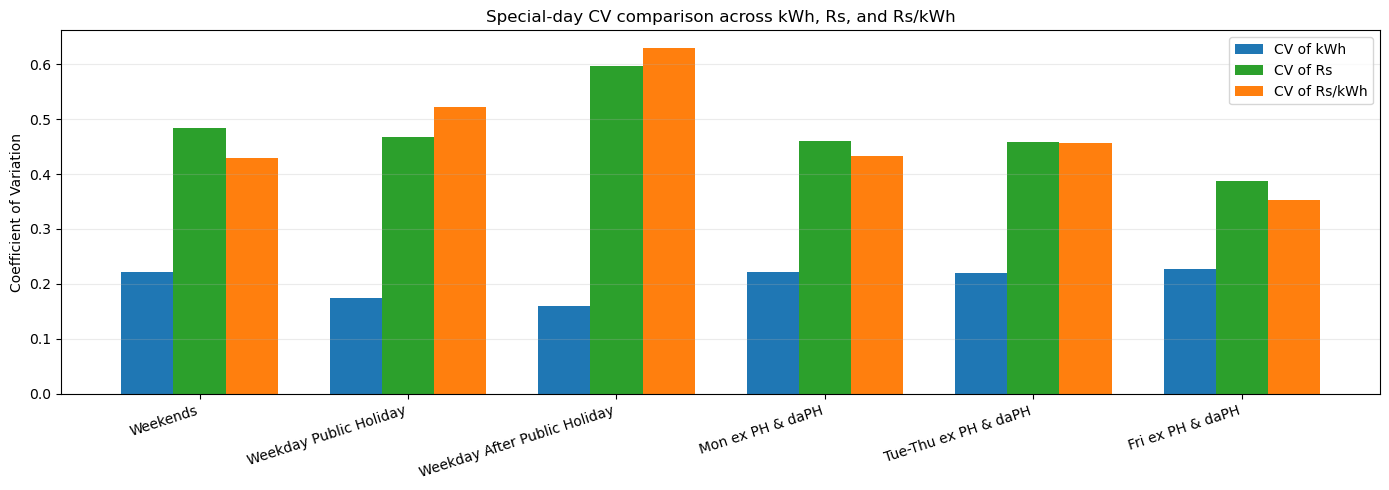

Saved special day CV chart to: F:\Secure\CashFlowMgmt\data\33kv_incoming_feeder_special_day_cv_comparison.png


In [23]:
special_day_cv_plot_df = special_day_summary_export_df.loc[
    special_day_summary_export_df["analysis_group"] != "Overall",
    ["analysis_group", "CV of kWh", "CV of Rs", "CV of Rs/kWh"],
].copy()
special_day_cv_plot_df["analysis_group"] = pd.Categorical(
    special_day_cv_plot_df["analysis_group"],
    categories=special_group_order,
    ordered=True,
)
special_day_cv_plot_df = special_day_cv_plot_df.sort_values("analysis_group").reset_index(drop=True)

x = np.arange(len(special_day_cv_plot_df))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - bar_width, special_day_cv_plot_df["CV of kWh"], width=bar_width, color="tab:blue", label="CV of kWh")
ax.bar(x, special_day_cv_plot_df["CV of Rs"], width=bar_width, color="tab:green", label="CV of Rs")
ax.bar(x + bar_width, special_day_cv_plot_df["CV of Rs/kWh"], width=bar_width, color="tab:orange", label="CV of Rs/kWh")
ax.set_xticks(x)
ax.set_xticklabels(special_day_cv_plot_df["analysis_group"], rotation=18, ha="right")
ax.set_ylabel("Coefficient of Variation")
ax.set_title("Special-day CV comparison across kWh, Rs, and Rs/kWh")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(special_day_cv_png_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved special day CV chart to: {special_day_cv_png_path}")

## Next TODOs

- profile the `Attribute` field to confirm whether additional long-format measures exist in future extracts
- add source-level data quality checks for missing dates, repeated meter-day rows, and abnormal spikes
- keep any later combined analysis separate and documented rather than forcing unsupported joins